# Agente de monitoramento de região alagada
#### Integrantes: José Luís Rodes Maciel Jr. & Victorio Battistello Faraco
No seguinte notebook, seguiremos um passo a passo da implementação de um agente de monitoramento de região alagada. O agente usará imagens de vista top-downe definirá se a regição está ou não inundada. Para isso, usaremos um modelo base com transfer-learning e acrecsentaremos as nossas próprias camadas para atingir este objetivo. Para treiná-lo, usaremos o dataset Louisiana Flood 2016, com imagens de uma inundação que ocorreu em 2016 no estado de Louisiana, nos Estados Unidos.
## Dependências
Para o desenvolvimento, usaremos as seguintes dependências:

In [ ]:
%pip install kagglehub
%pip install tensorflow keras
%pip install scikit-learn

## Importação do dataframe
Estamos importando o dataframe Louisiana Images 2016, com imagens referentes à uma cheia que ocorreu na região em 2016.

In [5]:
import kagglehub
import os
import shutil

data_dir = os.path.join(os.getcwd(), "content", "louisiana_images")
key_file = os.path.join(data_dir, "train.csv")

if not os.path.exists(key_file): # apenas faz o download caso o dataframe já não tenha sido baixado
    path = kagglehub.dataset_download("rahultp97/louisiana-flood-2016")

    os.makedirs(data_dir, exist_ok=True)

    shutil.copytree(path, data_dir, dirs_exist_ok=True)

    print(f"Dataframe copiado de {path} para {data_dir}")
else:
    print(f"Dataframe encontrado em {data_dir}")


Dataframe encontrado em c:\Projetos\Aula\ia_e_ml\college-AI-ML\desafio2\content\louisiana_images


## Imports gerais

In [6]:
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.utils import to_categorical
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

## Criação dos dataframes, processamento em datasets e das imagens

In [3]:
train_df = pd.read_csv(data_dir + '/train.csv')
test_df = pd.read_csv(data_dir + '/test.csv')

In [4]:
import tensorflow as tf
import os

image_size = (512, 360)
batch_size = 32

def preprocess_image_py(image_path_tensor, label):
    image_path = image_path_tensor.numpy().decode('utf-8')
    try:
        img = tf.io.read_file(image_path)
        img = tf.image.decode_image(img, channels=3)
        if img.shape.rank == 0:  # Verifica se a imagem está vazia
            raise ValueError(f"imagem vazia")
        img = tf.image.resize(img, image_size)
        img = tf.cast(img, tf.float32) / 255.0  # Normaliza para o intervalo [0, 1]
        return img, label
    except Exception as e:
        print(f"Erro ao processar a imagem {image_path}: {e}")
        # Retorna uma imagem preta preenchida com zeros como substituta
        return tf.zeros((*image_size, 3), dtype=tf.float32), label

def preprocess_image(image_path, label):
    processed_image, processed_label = tf.py_function(
        preprocess_image_py,
        inp=[image_path, label],
        Tout=[tf.float32, label.dtype]
    )
    processed_image.set_shape([*image_size, 3])
    processed_label.set_shape([])
    return processed_image, processed_label

# --- Criar Dataset de Treino ---
print("Criando dataset de treino...")
train_image_filenames = train_df['Image ID'].values
train_labels = train_df['Flooded'].values

train_image_paths = [os.path.join(data_dir, 'train', fname) for fname in train_image_filenames]

train_ds = tf.data.Dataset.from_tensor_slices((train_image_paths, train_labels))

train_ds = train_ds.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(buffer_size=len(train_image_paths)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# --- Criar Dataset de Teste ---
print("Criando dataset de teste...")
test_image_filenames = test_df['Image ID'].values
test_labels = test_df['Flooded'].values

test_image_paths = [os.path.join(data_dir, 'test', fname) for fname in test_image_filenames]

test_ds = tf.data.Dataset.from_tensor_slices((test_image_paths, test_labels))
test_ds = test_ds.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE) # Não embaralha o conjunto de teste

print("Datasets de treino e teste criados com sucesso.")
print(f"Número de amostras de treino: {len(train_image_paths)}")
print(f"Número de amostras de teste: {len(test_image_paths)}")

# Opcional: Verificar um batch do dataset de treino
for images, labels in train_ds.take(1):
    print(f"Formato do batch de imagens de treino: {images.shape}")
    print(f"Formato do batch de labels de treino: {labels.shape}")
    print(f"Tipo de dados do batch de imagens de treino: {images.dtype}")
    print(f"Tipo de dados do batch de labels de treino: {labels.dtype}")
    break

Criando dataset de treino...
Criando dataset de teste...
Datasets de treino e teste criados com sucesso.
Número de amostras de treino: 270
Número de amostras de teste: 52
Formato do batch de imagens de treino: (32, 512, 360, 3)
Formato do batch de labels de treino: (32,)
Tipo de dados do batch de imagens de treino: <dtype: 'float32'>
Tipo de dados do batch de labels de treino: <dtype: 'int64'>


In [7]:
for imgs, labels in train_ds.take(1):
    print("Valor mínimo:", tf.reduce_min(imgs).numpy())
    print("Valor máximo:", tf.reduce_max(imgs).numpy())

Valor mínimo: 0.0
Valor máximo: 1.0


## Construção do modelo

Usamos como base o modelo MobileNet (v1), congelando a base do modelo, para não treinarmos ele, e adicionando as camadas restantes necessárias para a sua função (classificação binária). Além disso usamos o transfer-learning para que não fosse necessário treinar completamente o novo modelo.

In [ ]:
from keras.applications import MobileNet
from keras.models import Model
from keras.layers import Dense, Flatten, Dropout
from keras.optimizers import Adam
from tensorflow.keras import layers

base_model = MobileNet(
    include_top=False,
    weights='imagenet',
    input_shape=(image_size[0], image_size[1], 3),  # Seu tamanho (512, 360, 3)
    alpha=1.0,
    depth_multiplier=1,
    dropout=0.001
)

# Congela as camadas do modelo base para não serem treinadas
base_model.trainable = False

x = base_model.output

# Camadas para classificação binária
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)

# Cria o modelo final
model = Model(inputs=base_model.input, outputs=output_layer)

# Compila o modelo
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# Exibe o resumo do modelo
model.summary()

print("Modelo de Transfer Learning criado e compilado com sucesso!")

## Treino do Modelo

Treinamos o modelo por 100 épocas, mais do que o necessário normalmente, mas queríamos um resultado um pouco mais preciso.

In [ ]:
# cria um checkpoint para salvar os pesos do melhor modelo encontrado no treinamento
checkpointer = ModelCheckpoint(filepath='model.weights.best.keras', verbose=1, save_best_only=True)

# treina o modelo
hist = model.fit(train_ds, epochs=100,
          validation_data=test_ds,
          callbacks=[checkpointer],
          verbose=2)

Infelizmente, os dados de treimaneto foram perdidos entre uma sessão e outra.

## Carregando os pesos do modelo treinado
Executando o código abaixo, carregamos os pesos salvos sem precisar treinar novamente o modelo.

In [9]:
model_path = "model.weights.best.keras"

model = tf.keras.models.load_model(model_path)
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 512, 360, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 256, 180, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 256, 180, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 256, 180, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 256, 180, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 256, 180, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 256, 180, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 256, 180, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 256, 180, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 256, 180, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 257, 181, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 128, 90, 64)    │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 128, 90, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 128, 90, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 128, 90, 128)   │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 128, 90, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 128, 90, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 128, 90, 128)   │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 128, 90, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 128, 90, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 128, 90, 128)   │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 128, 90, 128)   │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,231,941 (12.33 MB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 3,228,864 (12.32 MB)

 Optimizer params: 2,052 (8.02 KB)

## Resultado
### Criando variáveis para checagem de resultados
As variáveis criadas no trecho abaixo serão usadas para amostragem dos resultados no geral.

In [13]:
import numpy as np

# Listas para acumular
images_list = []
labels_list = []

for img_batch, lbl_batch in test_ds.unbatch().batch(1):
    images_list.append(img_batch.numpy()[0])
    labels_list.append(lbl_batch.numpy()[0])

# Converte para arrays
x_test = np.array(images_list)
y_test = np.array(labels_list)

y_hat_prob = model.predict(x_test)
y_hat = (y_hat_prob > 0.5).astype(int).flatten()

class_names = ['Não inundação', 'Inundação']

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step


### Matriz de Confusão
No geral o modelo desempenha bem, errando principalmente nos falsos negativos (quando o resultado esperado é "Inundação" e o modelo prediz "Não Inundação").

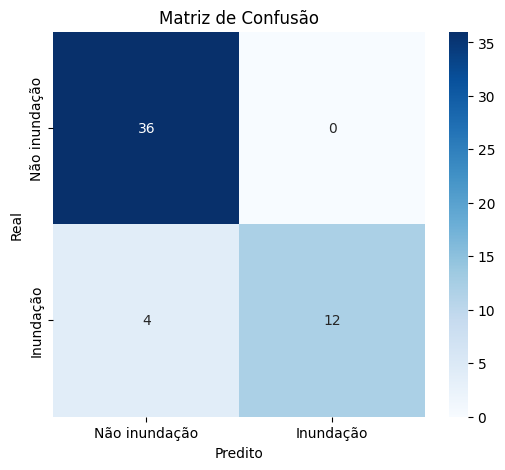

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_hat)
print("Matriz de confusão:\n", cm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não inundação', 'Inundação'],
            yticklabels=['Não inundação', 'Inundação'])
plt.title('Matriz de Confusão')
plt.ylabel('Real')
plt.xlabel('Predito')
plt.show()

### Métricas por classe
A classe de "Não Inundação" tem acurácia de 100%, e precisão de cerca de 90%, resultados quase perfeitos. Já a classe de "Inundação", fica um pouco abaixo, com um pouco menos de 80% de acurácia, mas quase 100% de precisão, ainda assim, também muito boa.

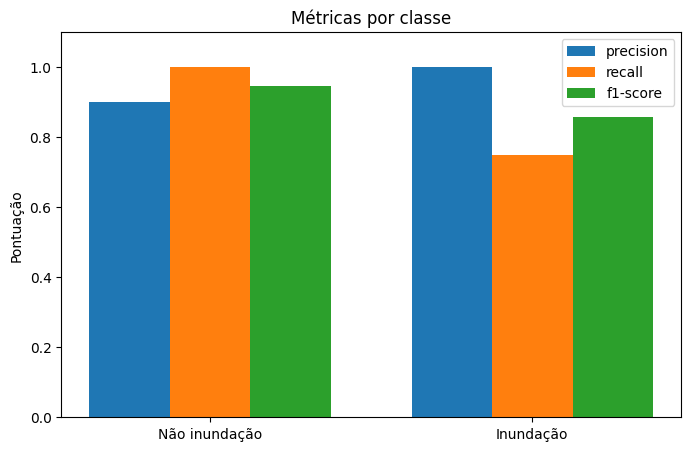

Acurácia no teste: 0.9231


In [ ]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_hat, target_names=['Não inundação', 'Inundação'], output_dict=True)
metrics = ['precision', 'recall', 'f1-score']
classes = ['Não inundação', 'Inundação']

x = np.arange(len(classes))
width = 0.25
fig, ax = plt.subplots(figsize=(8, 5))
for i, metric in enumerate(metrics):
    values = [report[cls][metric] for cls in classes]
    ax.bar(x + i*width, values, width, label=metric)

ax.set_xticks(x + width)
ax.set_xticklabels(classes)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Pontuação')
ax.set_title('Métricas por classe')
ax.legend()
plt.show()

### Tempo de processamento
O tempo médio de processamento é de menos de 200ms, um tempo bastante rápido para o propósito do agente, que seria alertar para que moradores saiam de casa em caso de inundação.

In [23]:
import time

tempos = []
for img in x_test:
    img_batch = np.expand_dims(img, axis=0)
    start = time.time()
    _ = model.predict(img_batch, verbose=0)
    end = time.time()
    tempos.append(end - start)

tempo_medio = np.mean(tempos)
tempo_total = np.sum(tempos)
print(f"Tempo médio por imagem: {tempo_medio*1000:.2f} ms")
print(f"Tempo total para {len(x_test)} imagens: {tempo_total:.2f} s")

start = time.time()
y_prob = model.predict(test_ds, verbose=1)
tempo_total = time.time() - start
print(f"Tempo total de predição no dataset de teste: {tempo_total:.2f} s")

Tempo médio por imagem: 193.70 ms
Tempo total para 52 imagens: 10.07 s
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step
Tempo total de predição no dataset de teste: 5.04 s


Ainda assim existem alguns outliers que passam um pouco esse tempo, mas não ultrapassam os 250ms.

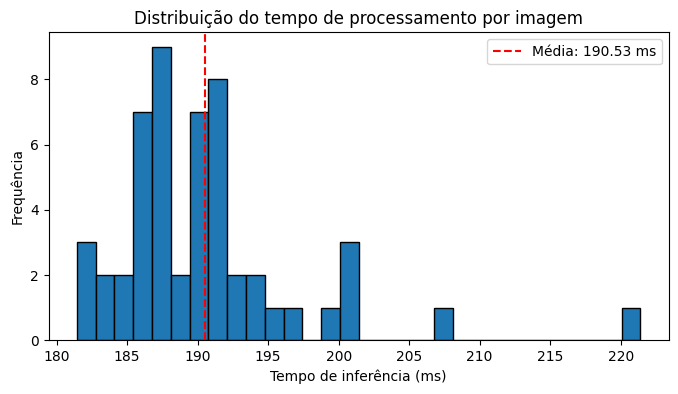

In [21]:
plt.figure(figsize=(8, 4))
plt.hist(np.array(tempos)*1000, bins=30, edgecolor='black')
plt.xlabel('Tempo de inferência (ms)')
plt.ylabel('Frequência')
plt.title('Distribuição do tempo de processamento por imagem')
plt.axvline(tempo_medio*1000, color='red', linestyle='dashed', label=f'Média: {tempo_medio*1000:.2f} ms')
plt.legend()
plt.show()

### Amostra de resultados
Aqui temos uma matriz de imagens e seus resultados, com a predição do modelo em cima e abaixo entre parênteses, a classe correta da imagem.

(52, 512, 360, 3) (52,)
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step


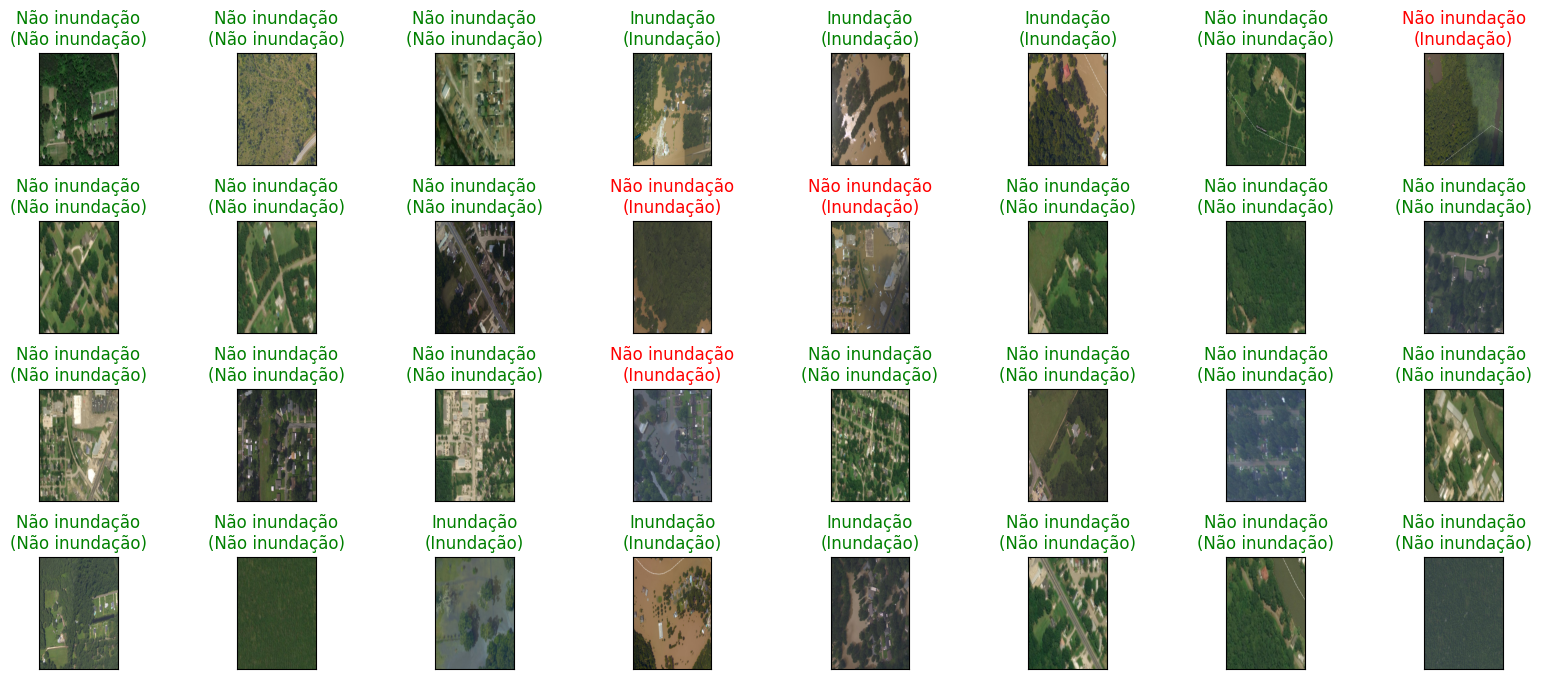

In [ ]:
fig = plt.figure(figsize=(20, 8))
for i, idx in enumerate(np.random.choice(x_test.shape[0], size=32, replace=False)):
    ax = fig.add_subplot(4, 8, i + 1, xticks=[], yticks=[])
    # Mostra a imagem (os valores estão entre 0 e 1; o imshow entende)
    ax.imshow(np.squeeze(x_test[idx]))
    pred_label = class_names[y_hat[idx]]
    true_label = class_names[y_test[idx]]
    color = "green" if y_hat[idx] == y_test[idx] else "red"
    ax.set_title(f"{pred_label}\n({true_label})", color=color)

fig.subplots_adjust(hspace=0.5)
plt.show()

---
# Atividade 2 – Agente de Monitoramento

Agente reativo que simula múltiplos sensores recebendo imagens de locais diferentes,
classifica cada imagem com o modelo treinado e emite alertas de enchente.

In [ ]:
import os, random, time
import numpy as np

# --- Sensor: representa um drone/câmera em um local ---
class Sensor:
    def __init__(self, nome, local, pasta):
        self.nome  = nome
        self.local = local
        self.imagens = [
            os.path.join(pasta, f) for f in os.listdir(pasta)
            if f.lower().endswith(('.png', '.jpg'))
        ]

    def capturar(self):
        """Devolve o caminho de uma imagem aleatória."""
        return random.choice(self.imagens)

# --- Agente de monitoramento: lê sensores e classifica ---
class AgenteMonitoramento:
    LIMIAR = 0.5

    def __init__(self, modelo, sensores):
        self.modelo   = modelo
        self.sensores = sensores

    def _classificar(self, caminho):
        img = tf.io.read_file(caminho)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, image_size)
        img = tf.cast(img, tf.float32) / 255.0
        t0  = time.perf_counter()
        prob = float(self.modelo.predict(img[None], verbose=0)[0][0])
        ms   = (time.perf_counter() - t0) * 1000
        return prob, ms

    def monitorar(self, ciclos=3):
        log = []
        print(f"Monitoramento iniciado — {len(self.sensores)} sensores, {ciclos} ciclos\n")
        for ciclo in range(1, ciclos + 1):
            print(f"--- Ciclo {ciclo} ---")
            for sensor in self.sensores:
                caminho = sensor.capturar()
                prob, ms = self._classificar(caminho)
                enchente = prob >= self.LIMIAR
                alerta   = "ALERTA" if enchente else "normal"
                print(f"  [{sensor.nome}] {sensor.local}")
                print(f"    {os.path.basename(caminho)} → {'Inundação' if enchente else 'Sem inundação'} "
                      f"({prob:.0%}) [{alerta}] | {ms:.0f} ms")
                log.append({"sensor": sensor.nome, "local": sensor.local,
                             "arquivo": os.path.basename(caminho),
                             "prob": prob, "enchente": enchente, "ms": ms})
            print()

        total    = len(log)
        enchentes = sum(r["enchente"] for r in log)
        print(f"Resumo: {enchentes}/{total} imagens com enchente detectada")
        print(f"Tempo médio de inferência: {np.mean([r['ms'] for r in log]):.0f} ms")
        return log

# --- Configuração e execução ---
sensores = [
    Sensor("DRONE-A", "Baton Rouge - Zona Norte",  os.path.join(data_dir, 'test')),
    Sensor("DRONE-B", "Lafayette - Margem do Rio", os.path.join(data_dir, 'test')),
    Sensor("CAM-01",  "New Orleans - Centro",      os.path.join(data_dir, 'test')),
    Sensor("CAM-02",  "Shreveport - Industrial",   os.path.join(data_dir, 'test')),
]

agente = AgenteMonitoramento(model, sensores)
log    = agente.monitorar(ciclos=3)